## Credit Risk Modelling

#### **Setup**
- The dataset contains 1,000 observations and a binary target variable, "Credit risk"
- EDA confirmed that there are no missing values or duplicate records
- The target variable is moderately imbalanced (70:30)
- The dataset does not include a meaningful temporal dimension (e.g. date)
- I mapped the "Credit risk" from Good:1 Bad:2 to Good:0 Bad:1
- I performed the stratified train_test_split (proportion 80:20)
- Model performance evalation was based on on AUC-ROC and AUC-PR
- Due to the small dataset size and resulting high variance, model performance was evaluated using stratified 10-fold cross-validation on the training set (800 observations).


#### **Features**
- **Categorical**
    - Status of existing checking account -  Categories: 4  ['A11', 'A13', 'A14', 'A12']
    - Credit history - Categories: 5 ['A33', 'A34', 'A32', 'A30', 'A31']
    - Purpose - Categories: 10 ['A49', 'A46', 'A41', 'A40', 'A43', 'A42', 'A45', 'A44', 'A410', 'A48']
    - Savings account/bonds - Categories: 5 ['A61', 'A63', 'A65', 'A62', 'A64']
    - Present employment since - Categories: 5  ['A75', 'A72', 'A73', 'A74', 'A71'] 
    - Installment rate in percentage of disposable income - Categories: 4 [1 2 3 4]
    - Personal status and sex - Categories: 4 ['A93', 'A91', 'A92', 'A94'] 
    - Other debtors / guarantors - Categories: 4 ['A101', 'A102', 'A103']
    - Present residence since - Categories: 4 [1 2 3 4]
    - Property -  Categories:4 ['A124', 'A123', 'A122', 'A121']
    - Other installment plans - Categories 3 ['A143', 'A141', 'A142']
    - Housing - Categories:4 ['A152', 'A151', 'A153']
    - Job - Categories:4  ['A173', 'A174', 'A172', 'A171']
    - Telephone - Categories:4 ['A192', 'A191'] - Binary variable
    - Foreign worker - Categories:4 ['A201', 'A202']

- **Numerical**
    - Duration in months - min:4 max: 60
    - Credit amount - min:250  max:18424
    - Age in years - min:19 max:75
    - Number of existing credits at this bank - min:1 max:4
    - Number of Accounts - min:1 max:2
    - Number of people being liable to provide maintenance for - min:1 max:2


#### **Summary**
The dataset is relatively small (1,000 observations), so I focused on models that are well-suited for tabular data and perform robustly in low-sample settings:
- Logistic Regression - I took this as a baseline model due to its simplicity, interpretability, and strong performance in credit risk modeling (especially with
    properly engineered features such as WoE or one-hot encoding)
- Random Forest - to capture non-linear relationships and interactions between features while maintaining robustness to overfitting
- XGBoost as a well known gradient boosting method, known for strong performance on structured/tabular data and its ability to model complex patterns
- CatBoost - a gradient boosting method specifically designed for datasets with categorical features. Unlike XGBoost, it handles categorical variables natively without requiring explicit encoding. It was included as a natural candidate given the high proportion of categorical features in this dataset

I decided not to try out the following models, as time was limited and stronger candidates were prioritized:

- Neural Networks – typically underperform on small tabular datasets and require significantly more data and tuning effort to generalize effectively compared to tree-based methods and linear models
- Probabilistic models (Naive Bayes, LDA, QDA) – rely on strong distributional assumptions (e.g., feature independence or Gaussianity), which are violated by the mixed categorical, binned, and non-normally distributed features in this dataset
- Support Vector Machines (SVM) – offer no clear performance or interpretability advantages in this setting and require careful tuning, making them less practical compared to tree-based approaches

Evaluation metrics used were AUC-ROC and AUC-PR:
- The dataset is moderately imbalanced (approximately 70:30), therefore both metrics provide complementary insights into model performance.
- AUC-ROC evaluates the model’s ability to discriminate between good and bad loans across all classification thresholds and remains informative under moderate class imbalance.
- AUC-PR (proxied here by average precision) on the other hand, focuses on performance for the positive class (bad loans), placing more emphasis on precision–recall trade-offs, which is particularly relevant in credit risk settings where correctly identifying risky loans is critical.

- Due to the limited dataset size and a relatively small test set (200 observations, ~65 positives), model performance was assessed using 10-fold cross-validation to obtain more stable and reliable estimates.

- In total I ran 7 models with the following results :
<div style="margin-left: 30px;">

| Model | Description                                      | AUC-ROC | PR-AUC | Recall | Precision |
|------|--------------------------------------------------|--------|--------|--------|-----------|
| 1    | Logistic Regression (baseline)                   | 0.78   | 0.606  | 0.70   | 0.503     |
| 2    | Logistic Regression (ordinal + feature eng.)     | 0.78   | 0.59   | 0.70   | 0.52      |
| 3    | Logistic Regression (WoE encoding)               | 0.795  | 0.62   | 0.72   | 0.53      |
| 4    | XGBoost                                         | 0.805  | 0.655  | 0.658  | 0.57      |
| 5    | Random Forest                                   | 0.802  | 0.657  | 0.588  | 0.598     |
| 6    | Balanced Random Forest                          | 0.804  | 0.645  | 0.683  | 0.524     |
| 7    | CatBoost                                        | 0.79  | 0.631  | 0.588  | 0.537     |

</div>
<br>

#### **Champion Model**

- A definitive champion cannot be selected at this stage; however, models 3, 4, 5, and 6 consistently outperformed models 1, 2, and 7.

- The underperformance of models 1 and 2 was expected, as both are simple linear classifiers with limited expressive power. Model 7 (CatBoost) was anticipated to perform well given its design for categorical datasets, but fell short of expectations. Its performance could likely be improved by refining the categorical encoding strategy and conducting a more thorough hyperparameter search.

- Model 3 is a classical choice in the risk scoring industry. Although it is also a linear model, its WoE encoding effectively captures non-linear relationships between features and the target variable, making it competitive with more complex approaches. Models 4, 5, and 6 are bagging and boosting ensembles, which are well-known to perform strongly on datasets with many categorical features and non-linear dynamics.

- It should be noted that given the small dataset size (~1,000 observations), evaluation metrics are likely subject to higher variance and may not be fully stable, even with cross-validation.

- Since this is a classification problem where false negatives can be particularly costly, recall may warrant more weight than precision in the final model selection. A false negative in this context means failing to flag a risky loan, which can carry significant financial consequences. To reach a definitive champion, the next steps would be to: 
    - (1) define the optimal Recall-Precision trade-off for the business context, and 
    - (2) tune the classification threshold for each candidate model accordingly. 
    
- With a larger dataset, any of models 3–7 could plausibly emerge as the champion.

#### **Remarks**

- Hyperparameter tuning: Optuna (Bayesian optimization) was informally explored for hyperparameter tuning of Random Forest. For XGBoost, ad-hoc experimentation suggested that the existing grid search already yields comparable performance.
- Class imbalance: SMOTE was briefly tested to address the 70:30 class imbalance but did not yield noticeable improvements and was not pursued further.
- KS metric: The Kolmogorov-Smirnov (KS) statistic was considered as an evaluation metric. While widely used in credit risk scorecard validation, it captures only the point of maximum separation between class distributions. AUC-ROC and AUC-PR were preferred as they summarize performance across all thresholds, providing a more complete picture.



#### Load the Data and Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, precision_score, 
    recall_score, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import shap
from category_encoders import WOEEncoder
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
from utils import print_cv_results

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# ── Custom transformers ───────────────────────────────────────────────────────
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.columns if c in X.columns])

class CastDtypes(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None, num_cols=None):
        self.cat_cols = cat_cols if cat_cols is not None else []
        self.num_cols = num_cols if num_cols is not None else []
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        if self.cat_cols:
            X[self.cat_cols] = X[self.cat_cols].astype("category")
        if self.num_cols:
            X[self.num_cols] = X[self.num_cols].astype("int64")
        return X
    
class WOEEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.encoder = WOEEncoder(cols=cols, regularization=1.5)
    def fit(self, X, y=None):
        self.encoder.fit(X, y)
        return self
    def transform(self, X):
        return self.encoder.transform(X)
    
df = pd.read_csv('../data/dataset.csv', index_col=0)

#### Model 1 - Logistic Regression (Baseline)
- Approach:
    - One-hot encoding performed for categorical variables
    - Numerical variables were left as is
    - Class weighting was performed

- This resulted in having 71 dimensions against a training set of only 800 observations (potential dimensionality issue)
    - To address this I experimented with L1 Regularization (which can serve as a feature selection tool) but it only worsened performance
    - L2 regularization however, has increased the average cross validation AUROC from 0.77 to 0.78
- Result (Cross-Validation): 
    - AUC ROC: 0.78 
    - PR-AUC:  0.606
    - Recall: 0.7
    - Precision: 0.503


── Cross Validation ─────────────────────────────────────────────

ROC-AUC per fold: [0.855 0.777 0.798 0.849 0.757 0.82  0.722 0.653 0.798 0.769]
ROC-AUC: 0.780 (+/- 0.057)

PR-AUC per fold: [0.701 0.629 0.662 0.681 0.503 0.664 0.5   0.439 0.691 0.588]
PR-AUC:  0.606 (+/- 0.089)

Recall per fold: [0.792 0.708 0.75  0.708 0.667 0.833 0.625 0.458 0.708 0.75 ]
Recall:  0.700 (+/- 0.098)

Precision per fold: [0.559 0.515 0.5   0.607 0.471 0.571 0.455 0.379 0.515 0.462]
Precision:  0.503 (+/- 0.063)

── Test set evaluation ──────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       140
           1       0.54      0.80      0.64        60

    accuracy                           0.73       200
   macro avg       0.72      0.75      0.72       200
weighted avg       0.79      0.73      0.75       200

ROC-AUC:              0.811904761904762
Precision-Recall AUC: 0.6531708500494395

Regularization zeroed o

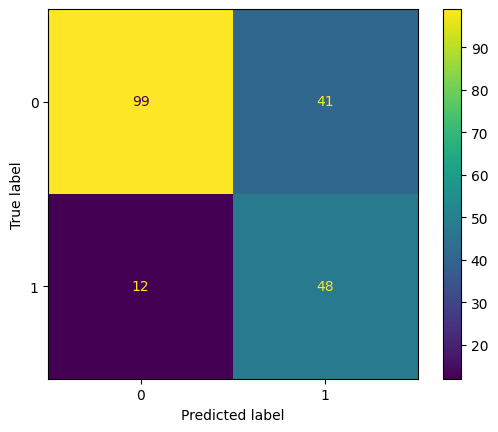

In [2]:


df_lr = df.copy()
X = df_lr.drop("Credit risk", axis=1)
y = df_lr["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────
categorical_columns = [
    "Status of existing checking account",
    "Credit history",
    "Purpose",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Other installment plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign worker",
]

numerical_columns = [

    "Number of existing credits at this bank",
    "Number of people being liable to provide maintenance for",
    "Credit amount",
    "Duration in months",
    "Age in years",
]


# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
    ]
)

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop",          DropColumns(["Number of Accounts",""])),
    ("cast",          CastDtypes(categorical_columns, numerical_columns)),
    ("preprocessing", preprocessor),
    ("model",         LogisticRegression(
                        penalty="l2",        
                        solver="liblinear",  
                        C=0.05,
                        max_iter=1000,
                        class_weight="balanced"
                      ))
])


# ── Cross validation  ─────────────────────────────────────────────────
print("── Cross Validation ─────────────────────────────────────────────")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_results = cross_validate(
    pipeline,
    X_train, 
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print_cv_results(cv_results)


# ── Train on train set, evaluate on held out test set ─────────────────────────
print("\n── Test set evaluation ──────────────────────────────────────────")

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", roc_auc_score(y_test, y_proba))
print("Precision-Recall AUC:", average_precision_score(y_test, y_proba))

# ── Check how many features Lasso zeroed out ──────────────────────────────────
reg_model = pipeline.named_steps["model"]
n_zero     = (reg_model.coef_[0] == 0).sum()
n_total    = len(reg_model.coef_[0])
print(f"\nRegularization zeroed out {n_zero}/{n_total} features")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
#RocCurveDisplay.from_predictions(y_test, y_proba)
#PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.show()

#### Model 2 - Logistic Regression with ordinal categorical values
- Approach:
    - Numerical features (Duration in Months, Credit Amount, Age in Years) were transformed into categorical features by grouping them into logical bins
    - Numerical features (Number of existing credits at this bank, Number of people being liable to provide maintenance for") were left out because that increased model performance
    - Following features were treated as ordinal - Credit amount, Duration in months, Age in years, Status of existing checking account, Credit history, Savings account/bonds, Personal status and sex, Other debtors / guarantors, Property, Other installment plans and Housing
    - For feature Purpose, the categories with low frequencies were merged into 'Other'
    - New categorical feature "monthly payment" was constructed by bining the: Credit amount / Duration in months
    - L2 Regularization was performed

- Result (Cross-validation): 
    - AUC ROC: 0.784
    - PR-AUC:  0.59
    - Recall:  0.704
    - Precision : 0.522

── Cross Validation ─────────────────────────────────────────────────────

ROC-AUC per fold: [0.847 0.798 0.815 0.833 0.725 0.813 0.743 0.732 0.833 0.699]
ROC-AUC: 0.784 (+/- 0.051)

PR-AUC per fold: [0.68  0.676 0.678 0.601 0.486 0.649 0.524 0.473 0.655 0.479]
PR-AUC:  0.590 (+/- 0.085)

Recall per fold: [0.75  0.667 0.75  0.708 0.583 0.792 0.792 0.583 0.75  0.667]
Recall:  0.704 (+/- 0.073)

Precision per fold: [0.529 0.485 0.562 0.548 0.519 0.528 0.5   0.519 0.581 0.444]
Precision:  0.522 (+/- 0.037)

── Test set evaluation ────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       140
           1       0.57      0.78      0.66        60

    accuracy                           0.76       200
   macro avg       0.73      0.77      0.74       200
weighted avg       0.79      0.76      0.77       200

ROC-AUC:              0.8185714285714286
Precision-Recall AUC: 0.6478194778554012

Regulari

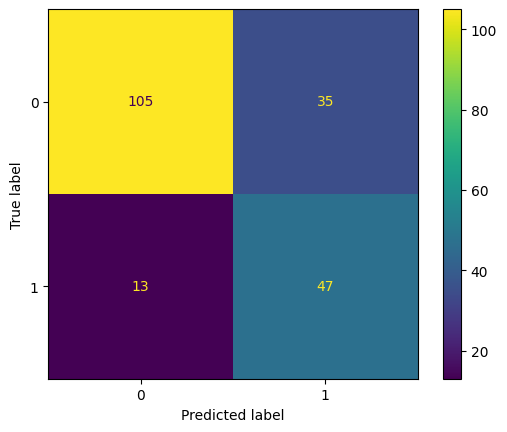

In [3]:

df_lr_2 = df.copy()


# ── Feature Engineering ────────────────────────────────────────────

purpose_replace = {'A45', 'A44', 'A410', 'A48'}
df_lr_2['Purpose'] = df_lr_2['Purpose'].apply(lambda x: 'Other' if x in purpose_replace else x)


df_lr_2["monthly_payment"]  = df_lr_2["Credit amount"] / df_lr_2["Duration in months"]
df_lr_2["monthly_payment"] = pd.cut(
    df_lr_2["monthly_payment"],
    bins=[0, 400, 800, 1200, 1600, 5000]
)

df_lr_2["Duration in months"] = pd.cut(
    df_lr_2["Duration in months"],
    bins=[0, 12, 24, 36, 48, 72]
)

df_lr_2["Credit amount"] = pd.cut(
    df_lr_2["Credit amount"],
    bins=[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 99999]
)

df_lr_2["Age in years"] = pd.cut(
    df_lr_2["Age in years"],
    bins=[0, 20, 30, 40, 50, 60, 99]
)

credit_cats   = sorted(df_lr_2["Credit amount"].cat.categories.tolist())
duration_cats = sorted(df_lr_2["Duration in months"].cat.categories.tolist())
age_cats      = sorted(df_lr_2["Age in years"].cat.categories.tolist())
monthly_payment_cats      = sorted(df_lr_2["monthly_payment"].cat.categories.tolist())


# ── Train Test Split ───────────────────────────────────────────────────────────

X = df_lr_2.drop("Credit risk", axis=1)
y = df_lr_2["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────
numerical_columns = [
]

ordinal_columns = [
    "Credit amount",
    "Duration in months",
    "Age in years",
    "Status of existing checking account",
    "Credit history",
    "Savings account/bonds",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Property",
    "Other installment plans",
    "Housing",
]

ordinal_categories = [
    credit_cats,
    duration_cats,
    age_cats,
    ['A14', 'A13', 'A12', 'A11'],
    ['A34', 'A33', 'A32', 'A31', 'A30'],
    ['A64', 'A63', 'A65', 'A61', 'A62'],
    ['A93', 'A94', 'A92', 'A91'],
    ['A103', 'A101', 'A102'],
    ['A121', 'A122', 'A123', 'A124'],
    ['A143', 'A142', 'A141'],
    ['A152', 'A151', 'A153'],
]

nominal_columns = [
    "monthly_payment",
    "Purpose",
    "Present employment since",
    "Personal status and sex",
    "Present residence since",
    "Job",
    "Telephone",
    "Foreign worker",
]

# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories),               ordinal_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_columns),
    ]
)

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop",          DropColumns(["Number of Accounts", ""])),
    ("cast",          CastDtypes(num_cols=numerical_columns)),
    ("preprocessing", preprocessor),
    ("model",         LogisticRegression(
                          penalty="l2",
                          solver="liblinear",
                          C=1000,
                          max_iter=1000,
                          class_weight="balanced"
                      ))
])

# ── Cross validation ──────────────────────────────────────────────────────────
print("── Cross Validation ─────────────────────────────────────────────────────")


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc":  "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print_cv_results(cv_results)

# ── Test set evaluation ───────────────────────────────────────────────────────
print("\n── Test set evaluation ────────────────────────────────────────────────")

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", roc_auc_score(y_test, y_proba))
print("Precision-Recall AUC:", average_precision_score(y_test, y_proba))

# ── Check how many features regularization zeroed out ────────────────────────
reg_model = pipeline.named_steps["model"]
n_zero  = (reg_model.coef_[0] == 0).sum()
n_total = len(reg_model.coef_[0])
print(f"\nRegularization zeroed out {n_zero}/{n_total} features")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

#### Model 3 - Logistic Regression + Feature Engineering + WOE encoding
- This was an attempt to improve upon the previous models by addressing:
    - The potential noise due to categories with low frequencies
    - One-hot encoding leading to having too many features

- Approach
    - For the feature "Purpose", categories with minor frequencies were clusterd into category 'Other'
    - Numerical features (Duration in Months, Credit Amount, Age in Years) were transformed into categorical features by grouping them into logical bins
    - I also experimented with treating the "Number of existing credits at this bank" and "Number of people being liable to provide maintenance for" as categorical variables but that didn't bring any improvement

    - I experimented with various values of L1 and L2 regularization but that didn't impact performance

    - All the categorical variables were WOE encoded - log(%good/%bad). This apprach is often used in combination with logistic regression since it approximately enforces a linear relationship with the target variable. In addition, this would reduce the number of model dimensions.


- Result (Cross-validation): 
    - AUC ROC: 0.795
    - PR-AUC:  0.62
    - Recall: 0.72
    - Precision: 0.53


── Cross Validation ──────────────────────────────────────────────────

ROC-AUC per fold: [0.859 0.784 0.836 0.822 0.737 0.859 0.734 0.728 0.842 0.749]
ROC-AUC: 0.795 (+/- 0.052)

PR-AUC per fold: [0.666 0.672 0.704 0.67  0.444 0.773 0.571 0.483 0.719 0.501]
PR-AUC:  0.620 (+/- 0.107)

Recall per fold: [0.792 0.708 0.792 0.708 0.708 0.833 0.667 0.583 0.708 0.708]
Recall:  0.721 (+/- 0.067)

Precision per fold: [0.613 0.548 0.543 0.5   0.5   0.588 0.457 0.538 0.586 0.447]
Precision:  0.532 (+/- 0.053)

── Test set evaluation ────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       140
           1       0.53      0.80      0.64        60

    accuracy                           0.73       200
   macro avg       0.71      0.75      0.71       200
weighted avg       0.78      0.73      0.74       200

ROC-AUC:              0.8002380952380952
Precision-Recall AUC: 0.6162292901854612


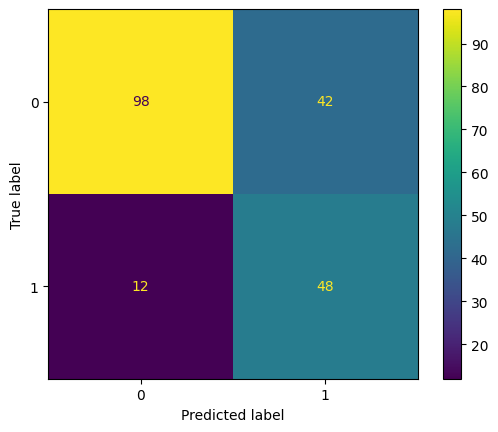

In [4]:
df_lr_3 = df.copy()

# ── Feature Engineering  ────────────────────────────────────────────────────

purpose_replace = {'A45', 'A44', 'A410', 'A48'}
df_lr_3['Purpose'] = df_lr_3['Purpose'].apply(lambda x: 'Other' if x in purpose_replace else x)

df_lr_3["monthly_payment"]  = df_lr_3["Credit amount"] / df_lr_3["Duration in months"]
df_lr_3["monthly_payment"] = pd.cut(
    df_lr_3["monthly_payment"],
    bins=[0, 400, 800, 1200, 1600, 5000]
)

df_lr_3["Duration in months"] = pd.cut(
    df_lr_3["Duration in months"],
    bins=[0, 12, 24, 36, 48, 72]
)

df_lr_3["Credit amount"] = pd.cut(
    df_lr_3["Credit amount"],
    bins=[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 99999]
)

df_lr_3["Age in years"] = pd.cut(
    df_lr_3["Age in years"],
    bins=[0, 20, 30, 40, 50, 60, 99]
)

# ── Train Test Split ──────────────────────────────────────────────────────────

X = df_lr_3.drop("Credit risk", axis=1)
y = df_lr_3["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────

numerical_columns = [
]

categorical_columns = [
    "monthly_payment",
    "Credit amount",
    "Duration in months",
    "Age in years",
    "Status of existing checking account",
    "Credit history",
    "Purpose",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Other installment plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign worker",
]


# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("woe", WOEEncoderWrapper(cols=categorical_columns), categorical_columns),
    ]
)

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop",          DropColumns(["Number of Accounts"])),
    ("cast",          CastDtypes(categorical_columns)),
    ("preprocessing", preprocessor),
    ("model",         LogisticRegression(
                        # penalty="l2",        # L1
                        # solver="liblinear",  # required for L1
                        # C=100,               # smaller = stronger
                        max_iter=2000,
                        class_weight="balanced"
                      ))
])

# ── Cross validation  ───────────────────────────────────────────────────────
print("── Cross Validation ──────────────────────────────────────────────────")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print_cv_results(cv_results)

# ── Test set evaluation ───────────────────────────────────────────────────────
print("\n── Test set evaluation ────────────────────────────────────────────────")

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", roc_auc_score(y_test, y_proba))
print("Precision-Recall AUC:", average_precision_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

#### Model 3 - View the WoE encoded dataset



In [5]:

preprocessing_pipeline = Pipeline([
    ("drop",          DropColumns(["Number of Accounts"])),
    ("cast",          CastDtypes(categorical_columns, numerical_columns)),
    ("preprocessing", preprocessor),
])

preprocessing_pipeline.fit(X_train, y_train)
X_train_transformed = preprocessing_pipeline.transform(X_train)
all_feature_names = categorical_columns + numerical_columns

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=all_feature_names,
    index=X_train.index
)

X_train_transformed_df.head()

,monthly_payment,Credit amount,Duration in months,Age in years,Status of existing checking account,Credit history,Purpose,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,Present residence since,Property,Other installment plans,Housing,Job,Telephone,Foreign worker
828,-0.029241,1.025935,0.452085,-0.167422,0.759093,0.101978,-0.538908,-0.721018,-0.177099,-0.047085,-0.194736,-0.014246,0.014473,0.682411,-0.150828,0.476717,-0.051012,0.072374,0.035128
997,-0.029241,0.154344,-0.497389,-0.194015,-1.116483,0.101978,-0.437787,0.286761,-0.177099,0.177164,-0.194736,-0.014246,0.014473,0.036634,-0.150828,-0.201039,-0.051012,0.072374,0.035128
148,-0.029241,-0.258394,0.452085,0.187029,0.759093,-0.682835,0.142133,0.286761,-0.108230,-0.047085,-0.194736,-0.326217,-0.032373,0.003086,-0.150828,-0.201039,-0.051012,0.072374,0.035128
735,-0.029241,-0.421253,0.452085,0.187029,0.409728,0.976794,0.200181,-0.721018,0.606280,-0.047085,0.261063,-0.014246,-0.032373,0.682411,0.665865,-0.201039,0.412774,0.072374,0.035128
130,-0.029241,1.025935,0.699636,0.187029,0.409728,0.101978,0.277610,-0.721018,-0.374466,-0.247030,0.261063,-0.014246,-0.032373,0.036634,-0.150828,-0.201039,-0.051012,0.072374,0.035128


#### Model 4 - XGBoost
- Approach
    - For the feature "Purpose", categories with minor frequencies were clusterd into category 'Other'
    - The "monthly payment" feature yielded no improvement to performance, so I excluded it
    - Other features were left as is
    - Categorical features were one-hot encoded. This yielded better performance than XgBoost native encoder

- Result (Cross-validation): 
    - AUC ROC: 0.805
    - PR-AUC:  0.655
    - Recall: 0.658
    - Precision: 0.57

── Cross Validation + Default model setup ───────────────────────────────

ROC-AUC per fold: [0.856 0.753 0.802 0.713 0.781 0.751 0.792 0.638 0.754 0.786]
ROC-AUC: 0.763 (+/- 0.055)

PR-AUC per fold: [0.735 0.645 0.706 0.506 0.643 0.555 0.633 0.409 0.57  0.676]
PR-AUC:  0.608 (+/- 0.094)

Recall per fold: [0.625 0.583 0.667 0.5   0.542 0.625 0.583 0.292 0.542 0.667]
Recall:  0.562 (+/- 0.104)

Precision per fold: [0.714 0.636 0.64  0.414 0.591 0.577 0.583 0.389 0.542 0.533]
Precision:  0.562 (+/- 0.095)

── Cross Validation + Grid Search ─────────────────────────────────────
Fitting 10 folds for each of 216 candidates, totalling 2160 fits

Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 400, 'model__subsample': 0.7}
Best CV ROC-AUC: 0.805

ROC-AUC per fold: [0.879 0.801 0.835 0.816 0.802 0.813 0.778 0.696 0.808 0.824]
ROC-AUC: 0.805 (+/- 0.044)

PR-AUC per fold: [0.78  0.717 0.784 0.58  0.58  0.65  0.61  0.445 

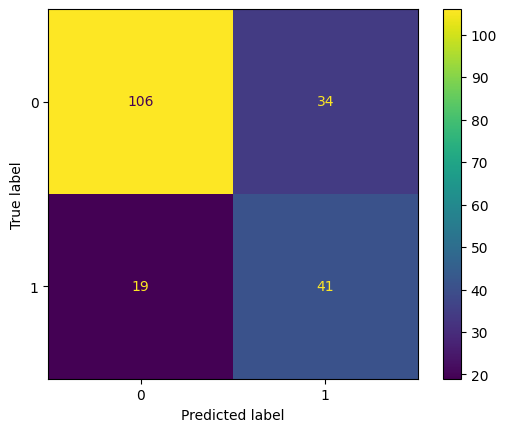

In [6]:

df_xgb = df.copy()

# ── Feature Engineering ────────────────────────────────────────────

purpose_replace = {'A45', 'A44', 'A410', 'A48'}
df_xgb['Purpose'] = df_xgb['Purpose'].apply(lambda x: 'Other' if x in purpose_replace else x)

# ── Train Test Split ──────────────────────────────────────────────────────────

X = df_xgb.drop("Credit risk", axis=1)
y = df_xgb["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────
numerical_columns = [
    "Credit amount",
    "Duration in months",
    "Age in years",
    "Number of existing credits at this bank",
    "Number of people being liable to provide maintenance for",
]

categorical_columns = [
    "Status of existing checking account",
    "Credit history",
    "Savings account/bonds",
    "Installment rate in percentage of disposable income",
    "Other debtors / guarantors",
    "Property",
    "Other installment plans",
    "Housing",
    "Purpose",
    "Present residence since",
    "Present employment since",
    "Personal status and sex",
    "Job",
    "Telephone",
    "Foreign worker",
]

# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                          numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
    ]
)

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop",          DropColumns(["Number of Accounts"])),
    ("cast",          CastDtypes(numerical_columns)),
    ("preprocessing", preprocessor),
    ("model",         XGBClassifier(
                          scale_pos_weight=sum(y_train==0)/sum(y_train==1),
                          objective="binary:logistic",
                          eval_metric="auc", # alternative: "aucpr"
                          random_state=42,
                      ))
])

# ── Cross validation  ───────────────────────────────────────── for DEFAULT MODEL
print("── Cross Validation + Default model setup ───────────────────────────────")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_results = cross_validate(
    pipeline,
    X_train, 
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print_cv_results(cv_results)


# ── CV + Grid search ──────────────────────────────────────────────────────────
print("\n── Cross Validation + Grid Search ─────────────────────────────────────")

param_grid = {
    "model__n_estimators":     [400, 500, 600],
    "model__max_depth":        [4, 5, 6],
    "model__learning_rate":    [0.01, 0.05],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample":        [0.6, 0.7, 0.8],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc", # alternative: "average_precision"
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
#grid_search.fit(X, y)

print("\nBest parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

best_pipeline = grid_search.best_estimator_

# This allows us to look at both metrics per fold
cv_results_best = cross_validate(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print_cv_results(cv_results_best)

# ── Evaluate best model on test set ──────────────────────────────────────────
print("\n── Test set evaluation ───────────────────────────────────────────────")

y_pred  = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", roc_auc_score(y_test, y_proba))
print("Precision-Recall AUC:", average_precision_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

#### Model 4 - SHAP values
- The SHAP feature importance plot shows that the model is primarily driven by:
    - checking account status
    - loan duration
    - credit amount
    - credit history
    - savings accounts/bond

- Other features are contributing to a lesser extent

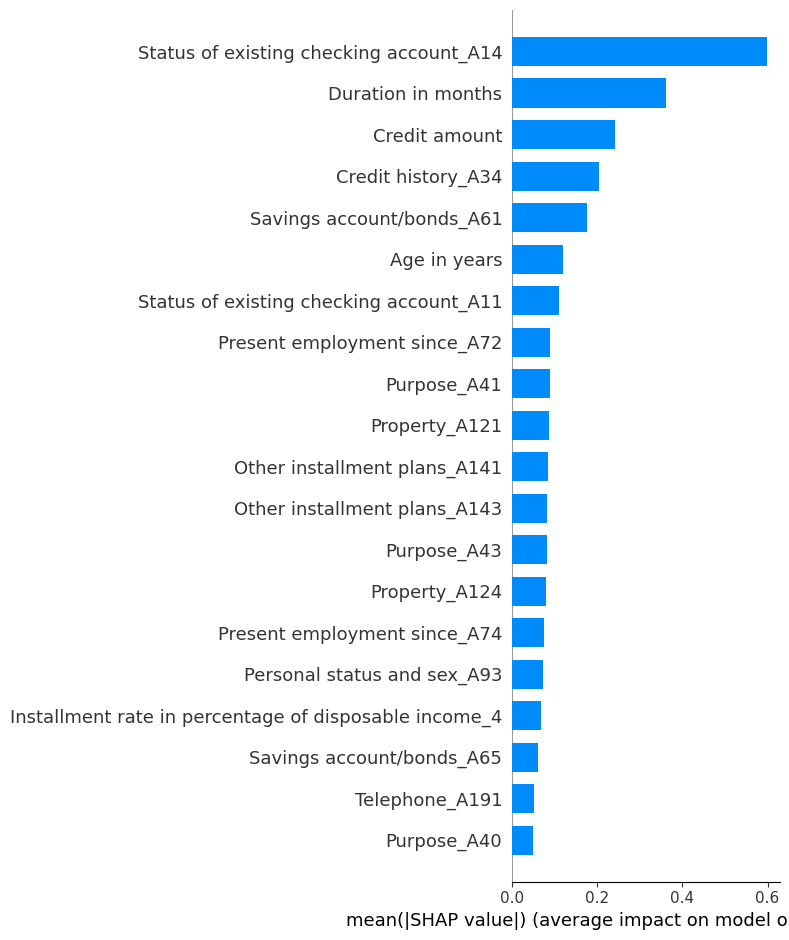

In [7]:

# ── Fit the best pipeline from grid search ────────────────────────────────────
best_pipeline = grid_search.best_estimator_

# ── Get the preprocessed X_test ──────────────────────────────────────────────
preprocessor_steps = Pipeline(best_pipeline.steps[:-1])  # all steps except model
X_test_transformed = preprocessor_steps.transform(X_test)

# ── Get feature names ─────────────────────────────────────────────────────────
num_feature_names = numerical_columns
cat_feature_names = (best_pipeline
                     .named_steps["preprocessing"]
                     .named_transformers_["cat"]
                     .get_feature_names_out(categorical_columns)
                     .tolist())

all_feature_names = num_feature_names  + cat_feature_names

# ── SHAP values ───────────────────────────────────────────────────────────────
model = best_pipeline.named_steps["model"]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot — global feature importance
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type="bar"
)

#### Model 5 - Random Forest
- Approach
    - For the feature "Purpose" the categories with minor frequencies were clustered into category 'Other'
    - The "monthly payment" engineered feature yielded an improvement so I included it
    - I tried constructing a number of other features such as "amount per age" or "amount_x_duration" however none had material impact on model performance, so I excluded them
    - Other features were left as is

- Result (Cross-validation): 
    - AUC ROC: 0.802 
    - PR-AUC:  0.657
    - Recall: 0.588 
    - Precision: 0.598


── Cross Validation + Grid Search ──────────────────────────────────
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best parameters: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__min_impurity_decrease': 0.0, 'model__max_samples': 0.9, 'model__max_features': 'log2', 'model__max_depth': None, 'model__criterion': 'gini'}
Best CV ROC-AUC: 0.802

ROC-AUC per fold: [0.864 0.827 0.852 0.801 0.785 0.807 0.788 0.686 0.794 0.818]
ROC-AUC: 0.802 (+/- 0.046)

PR-AUC per fold: [0.742 0.735 0.771 0.585 0.574 0.628 0.655 0.479 0.67  0.734]
PR-AUC:  0.657 (+/- 0.088)

Recall per fold: [0.667 0.583 0.708 0.5   0.583 0.708 0.583 0.25  0.542 0.75 ]
Recall:  0.588 (+/- 0.136)

Precision per fold: [0.667 0.667 0.654 0.6   0.583 0.607 0.56  0.5   0.565 0.581]
Precision:  0.598 (+/- 0.050)

── Test set evaluation ─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.83     

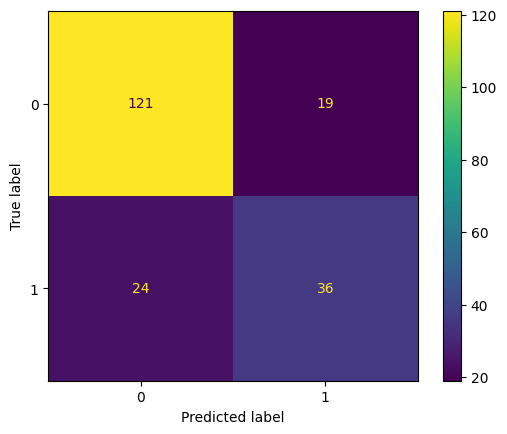

In [8]:
df_rf = df.copy()

# ── Feature Engineering ───────────────────────────────────────────────────────

purpose_replace = {'A45', 'A44', 'A410', 'A48'}
df_rf['Purpose'] = df_rf['Purpose'].apply(lambda x: 'Other' if x in purpose_replace else x)
df_rf["monthly_payment"]  = df_rf["Credit amount"] / df_rf["Duration in months"]

# df_rf["amount_x_rate"]    = df_rf["Credit amount"] * df_rf["Installment rate in percentage of disposable income"]
# df_rf["amount_per_age"]   = df_rf["Credit amount"] / df_rf["Age in years"]
# df_rf["amount_x_duration"] = df_rf["Credit amount"] * df_rf["Duration in months"]
# df_rf["young_high_loan"] = ((df_rf["Age in years"] < 30) & (df_rf["Credit amount"] > 5000)).astype(int)
# df_rf["no_account_high_loan"] = ((df_rf["Status of existing checking account"] == "A14") & (df_rf["Credit amount"] > 5000)).astype(int)
# df_rf["unemployed_long_loan"] = ((df_rf["Present employment since"] == "A71") & (df_rf["Duration in months"] > 24)).astype(int)
# df_rf["credits_per_year"] = df_rf["Number of existing credits at this bank"] / (df_rf["Duration in months"] / 12)

# ── Train Test Split ──────────────────────────────────────────────────────────
X = df_rf.drop("Credit risk", axis=1)
y = df_rf["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────

numerical_columns = [
    "Credit amount",
    "Duration in months",
    "Age in years",
    "monthly_payment",
    "Number of existing credits at this bank",
    "Number of people being liable to provide maintenance for",
    # "amount_x_rate",
    # "amount_per_age",
    # "amount_x_duration",
    # "young_high_loan",
    # "no_account_high_loan",
    # "unemployed_long_loan",
    # "credits_per_year"
]

categorical_columns = [
    "Status of existing checking account",
    "Credit history",
    "Purpose",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Other installment plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign worker",
]

# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_columns),
        #("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
    ]
)

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop", DropColumns(["Number of Accounts"])),
    ("cast", CastDtypes(numerical_columns)),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


# ── CV + Grid search ───────────────────────────────────────────────────────
print("\n── Cross Validation + Grid Search ──────────────────────────────────")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid = {
    "model__n_estimators":      [100, 200, 300, 500],
    "model__max_depth":         [5, 7, 9, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [2, 4, 6],
    "model__max_samples":       [0.7, 0.8, 0.9, None],
    "model__max_features":      ["sqrt", "log2", 0.5],
    "model__criterion":         ["gini", "entropy"],  # splitting criterion
    "model__min_impurity_decrease": [0.0, 0.01, 0.05],  # pruning
}

grid_search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",   # alternative: "average_precision"
    n_jobs=-1,
    verbose=1,
    random_state=42
)

grid_search.fit(X_train, y_train)
#grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

best_pipeline = grid_search.best_estimator_

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_results_best = cross_validate(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print_cv_results(cv_results_best)


# ── Evaluate on test set ───────────────────────────────────────────────────
print("\n── Test set evaluation ─────────────────────────────────────────────")

y_proba = grid_search.predict_proba(X_test)[:, 1]
y_pred  = grid_search.predict(X_test)

#threshold = 0.45
#y_pred = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", roc_auc_score(y_test, y_proba))
print("Precision-Recall AUC:", average_precision_score(y_test, y_proba))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

#### Model 6 - Balanced Random Forest Classifier
- Approach
    - I applied the same feature engineering approach as for the Random Forest:
        - Low-frequency categories in the "Purpose" feature were grouped into an "Other" category to reduce sparsity
        - The engineered feature "monthly payment" improved model performance and was therefore retained
        - Additional engineered features (e.g., amount per age, amount × loan duration) were tested but showed no material impact on performance and were excluded
        - All remaining features were kept unchanged

- Result (Cross-validation): 
    - AUC ROC: 0.804
    - PR-AUC:  0.645
    - Recall: 0.683
    - Precision: 0.524


── Cross Validation + Grid Search ───────────────────────────────────
Fitting 10 folds for each of 512 candidates, totalling 5120 fits
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 15, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.804

ROC-AUC per fold: [0.867 0.825 0.847 0.795 0.769 0.824 0.783 0.7   0.794 0.836]
ROC-AUC: 0.804 (+/- 0.045)

PR-AUC per fold: [0.744 0.709 0.784 0.58  0.53  0.672 0.584 0.459 0.634 0.754]
PR-AUC:  0.645 (+/- 0.101)

Recall per fold: [0.875 0.708 0.75  0.583 0.625 0.75  0.625 0.417 0.667 0.833]
Recall:  0.683 (+/- 0.125)

Precision per fold: [0.583 0.586 0.545 0.483 0.469 0.529 0.484 0.476 0.571 0.513]
Precision:  0.524 (+/- 0.043)

── Test set evaluation ───────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.84      0.72      0.78       140
           1       0.51      0.68      0.59        60

    a

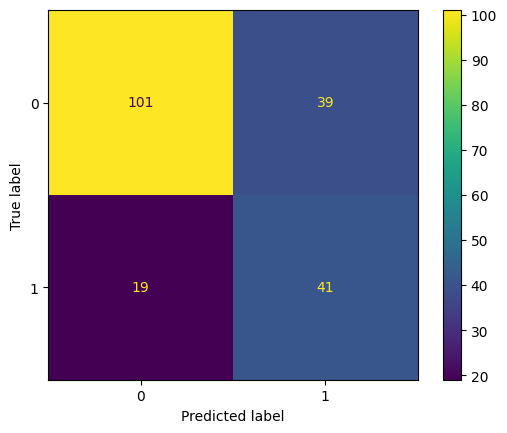

In [9]:
df_brf = df.copy()

# ── Feature Engineering ──────────────────────────────────────────────────────

purpose_replace = {'A45', 'A44', 'A410', 'A48'}
df_brf['Purpose'] = df_brf['Purpose'].apply(lambda x: 'Other' if x in purpose_replace else x)
df_brf["monthly_payment"]  = df_brf["Credit amount"] / df_brf["Duration in months"]


# ── Train Test Split ──────────────────────────────────────────────────────────
X = df_brf.drop("Credit risk", axis=1)
y = df_brf["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────

numerical_columns = [
    "Credit amount",
    "Duration in months",
    "Age in years",
    "monthly_payment",
    "Number of existing credits at this bank",
    "Number of people being liable to provide maintenance for",
]

categorical_columns = [
    "Status of existing checking account",
    "Credit history",
    "Purpose",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Other installment plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign worker",
]

# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_columns),
    ]
)

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop",          DropColumns(["Number of Accounts"])),
    ("cast",          CastDtypes(numerical_columns)),
    ("preprocessing", preprocessor),
    ("model",         BalancedRandomForestClassifier(
                          random_state=42,
                          n_jobs=-1
                      ))
])

# ── Grid search ─────────────────────────────────────────────────────────────
print("\n── Cross Validation + Grid Search ───────────────────────────────────")

param_grid = {
    "model__n_estimators":      [50, 100, 200, 300],
    "model__max_depth":         [3, 5, 7, None],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf":  [1, 2, 4, 8],
    "model__max_features":      ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))


best_pipeline = grid_search.best_estimator_

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_results_best = cross_validate(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print_cv_results(cv_results_best)


# ── Evaluate on test set ─────────────────────────────────────────────────────
print("\n── Test set evaluation ───────────────────────────────────────────────")

y_proba = grid_search.predict_proba(X_test)[:, 1]
y_pred  = grid_search.predict(X_test)

#threshold = 0.5
#y_pred = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", roc_auc_score(y_test, y_proba))
print("Precision-Recall AUC:", average_precision_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

#### Model 7 - CatBoost
- Approach
    - I applied the same feature approach as for the XGBoost model, with the addition of the monthly_payment feature, which provided a minor improvement in performance
    - Class weighting was performed
    - Encoding of categorical features is performed internally by the algorithm

- Result (Cross-validation): 
    - AUC ROC: 0.79
    - PR-AUC:  0.631
    - Recall: 0.588
    - Precision: 0.537


── Cross Validation + Grid Search ─────────────────────────────────────
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best parameters: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__iterations': 300, 'model__depth': 6, 'model__cat_features': ['Status of existing checking account', 'Credit history', 'Purpose', 'Savings account/bonds', 'Present employment since', 'Installment rate in percentage of disposable income', 'Personal status and sex', 'Other debtors / guarantors', 'Present residence since', 'Property', 'Other installment plans', 'Housing', 'Job', 'Telephone', 'Foreign worker']}
Best CV ROC-AUC: 0.79

── Cross Validation Metrics (best estimator) ───────────────────────────

Metric       Per-fold scores                                                Mean     Std
------------------------------------------------------------------------------------------
roc_auc      [0.874 0.833 0.788 0.746 0.743 0.839 0.777 0.679 0.804 0.819] 0.790  (+/- 0.054)
pr

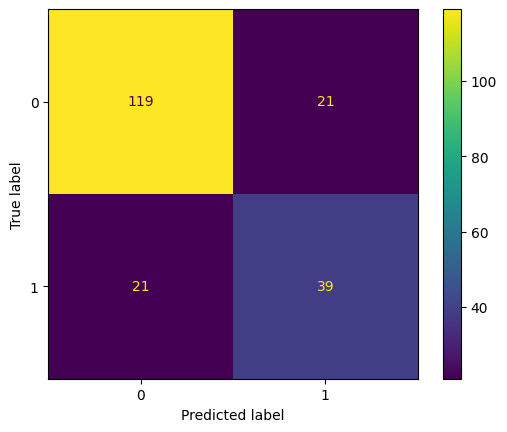

In [17]:
df_cb = df.copy()

# ── Feature Engineering ───────────────────────────────────────────────────────
purpose_replace = {'A45', 'A44', 'A410', 'A48'}
df_cb['Purpose'] = df_cb['Purpose'].apply(lambda x: 'Other' if x in purpose_replace else x)
df_cb["monthly_payment"]   = df_cb["Credit amount"] / df_cb["Duration in months"]

# ── Train Test Split ──────────────────────────────────────────────────────────
X = df_cb.drop("Credit risk", axis=1)
y = df_cb["Credit risk"].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ── Column definitions ────────────────────────────────────────────────────────
numerical_columns = [
    "Credit amount",
    "Duration in months",
    "Age in years",
    "monthly_payment",
    "Number of existing credits at this bank",
    "Number of people being liable to provide maintenance for",
]

categorical_columns = [
    "Status of existing checking account",
    "Credit history",
    "Purpose",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Other installment plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign worker",
]

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("drop",  DropColumns(["Number of Accounts"])),
    ("cast",  CastDtypes(categorical_columns, numerical_columns)),
    ("model", CatBoostClassifier(
                  auto_class_weights="Balanced",
                  random_state=42,
                  verbose=0,
                  #cat_features=categorical_columns
              ))
])

# ── CV + Grid search ───────────────────────────────────────────────────────────
print("\n── Cross Validation + Grid Search ─────────────────────────────────────")

param_grid = {
    "model__iterations":    [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__depth":         [3, 4, 6, 8],
    "model__l2_leaf_reg":   [1, 3, 5, 10],
    "model__cat_features":  [categorical_columns],
}

grid_search = RandomizedSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring="roc_auc",
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

# ── Per-fold metrics (manual loop to avoid CatBoost cloning issue) ─────────────
print("\n── Cross Validation Metrics (best estimator) ───────────────────────────")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
best_model = grid_search.best_estimator_

fold_scores = {m: [] for m in ["roc_auc", "pr_auc", "precision", "recall"]}

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_model.fit(X_tr, y_tr)
    y_proba_val = best_model.predict_proba(X_val)[:, 1]
    y_pred_val  = best_model.predict(X_val)

    fold_scores["roc_auc"].append(roc_auc_score(y_val, y_proba_val))
    fold_scores["pr_auc"].append(average_precision_score(y_val, y_proba_val))
    fold_scores["precision"].append(precision_score(y_val, y_pred_val, zero_division=0))
    fold_scores["recall"].append(recall_score(y_val, y_pred_val))

print(f"\n{'Metric':<12} {'Per-fold scores':<60} {'Mean':>6}  {'Std':>6}")
print("-" * 90)

for metric, scores in fold_scores.items():
    scores = np.array(scores)
    print(f"{metric:<12} {str(np.round(scores, 3)):<60} {scores.mean():.3f}  (+/- {scores.std():.3f})")

# ── Evaluate on test set ───────────────────────────────────────────────────────
print("\n── Test set evaluation ────────────────────────────────────────────────")

y_pred  = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:             ", round(roc_auc_score(y_test, y_proba), 3))
print("Precision-Recall AUC:", round(average_precision_score(y_test, y_proba), 3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()